## 1. The Image Classification Dataset

One widely used dataset for image classification is the **MNIST dataset** (LeCun et al., 1998) of handwritten digits. While it served as a benchmark for over a decade, modern simple models can achieve over 95% accuracy, making it unsuitable for distinguishing between strong and weak models today.

To provide a more relevant challenge, we use the **Fashion-MNIST dataset** (Xiao et al., 2017). It is qualitatively similar to MNIST but contains images of 10 categories of clothing. It consists of:
* **60,000** training images
* **10,000** test images
* **Resolution:** $28 \times 28$ pixels (grayscale)

We will use standard PyTorch libraries (`torch`, `torchvision`) to handle data loading and processing.

## 1. Setup and Imports

We begin by importing the necessary libraries. We will use `torch` for the neural network backend and `torchvision` for handling the image data. We also check if a GPU is available to speed up computation.

In [8]:
%matplotlib inline
import time
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms

#check gpu is available
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)



Using device: cpu


## 2. The Fashion-MNIST Dataset Class

We create a wrapper class to handle the **Fashion-MNIST** dataset. This dataset serves as a more challenging alternative to the original MNIST digits, containing 10 categories of clothing.

In the `__init__` method, we define a transformation pipeline. `transforms.ToTensor()` converts the images from PIL format (0-255) to PyTorch FloatTensors (0.0-1.0). We also allow for optional resizing, which is useful for testing different model architectures.

In [ ]:
class FashionMNIST:
    def __init__(self,batch_size=64,resize=(28,28),root='./data'):
        self.batch_size=batch_size
        self.root=root
        
        # --- The Transformation Pipeline ---
        # transforms.Compose combines multiple steps into one tool.
        # Step 1: Resize the image (e.g., to 32x32 pixels). 
        #         Essential if your model expects a specific input size.
        # Step 2: Convert to Tensor. 
        #         - Converts PIL Image or numpy.ndarray (H x W x C) in range [0, 255]
        #         - To torch.FloatTensor (C x H x W) in range [0.0, 1.0]
        self.trans=transforms.Compose([
            transforms.Resize(resize),
            transforms.ToTensor()
        ])

        #download the dataset
        self.train=torchvision.datasets.FashionMNIST(root=self.root,train=True,transform=self.trans,download=True)
        self.val=torchvision.datasets.FashionMNIST(root=self.root,train=False,transform=self.trans,download=True)

    def text_labels(self,indices):
        """Return text labels for the given numeric indices."""
        labels=['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
        return [labels[int (i)] for i in indices]
        
    def get_dataloader(self,train=True):
        #generates a dataloader for train or validation dataset
        dataset=self.train if train else self.val
        return DataLoader(dataset,batch_size=self.batch_size,shuffle=train,num_workers=4)
        #number of workers refers to the number of subprocesses to use for data loading. 0 means that the data will be loaded in the main process.
        #since using gpu we can set num_workers to 4 to speed up data loading
        
data=FashionMNIST(resize=(32,32))
print(f"Training set size: {len(data.train)}")
print(f"Validation set size: {len(data.val)}")
train_loader=data.get_dataloader(train=True)
X,y=next(iter(train_loader))
print(f"Batch shape: {X.shape}")
print(f"Batch labels shape: {y.shape}")

Training set size: 60000
Validation set size: 10000
Batch shape: torch.Size([64, 1, 32, 32])
Batch labels shape: torch.Size([64])


## 3. Visualization Utility

To inspect our data, we need a function to display the images. PyTorch tensors store images as $(C, H, W)$ (Channels, Height, Width), but `matplotlib` expects $(H, W, C)$. We use `.permute(1, 2, 0)` to rearrange the dimensions for plotting.

In [ ]:
def show_images(imgs,num_rows,num_cols,title=None,scale=1.5):
    #plot a list of images with specified rows and columns
    # Calculate total canvas size (Width, Height) in inches
    # Example: 8 cols * 1.5 scale = 12 inches wide
    figsize=(num_cols*scale,num_rows*scale)
    #_: the figure object(ignore),axes: the array of plot objects for each subplot
    _,axes=plt.subplots(num_rows,num_cols,figsize=figsize)
    axes=axes.flatten()
    for i,(ax,img) in enumerate(zip(axes,imgs)):
        if torch.is_tensor(img):
            #tensor image:permute the dimensions from (C,H,W) to (H,W,C) and convert to numpy array
            ax.imshow(img.permute(1,2,0).numpy(),cmap='gray')
        else:
            #PIL image: directly display
            ax.imshow(img,cmap='gray')
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if title:
            ax.set_title(title[i])
    plt.show()
    

### 4. Visualizing a Batch

Now we can inspect the first few images from the batch we loaded earlier. This serves as a sanity check to ensure our labels match the images and that the resizing worked as expected.

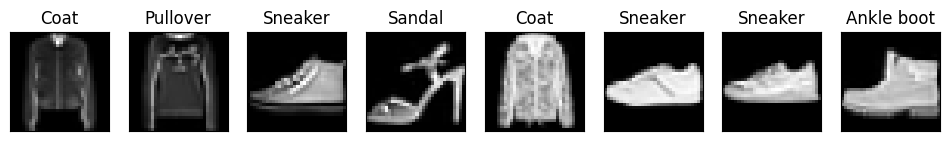

In [11]:
#visulaize the first 8 images in the batch
X_sample=X[:8]
y_sample=y[:8]
titles=data.text_labels(y_sample)
show_images(X_sample,num_rows=1,num_cols=8,title=titles)


## 5. The Classifier Base Class

We define a reusable base class for our models. This class inherits from `torch.nn.Module`. 

We include a method to calculate **Accuracy**, which is the primary metric for classification success.
$$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^n \mathbb{1}(\text{argmax}(\hat{y}^{(i)}) = y^{(i)})$$
This compares the index of the highest predicted probability against the true label.

In [ ]:
class Classifier(torch.nn.Module):
    #the base class of classification model
    def __init__(self):
        super().__init__()
    def accuracy(self,Y_hat,Y,averaged=True):
        #compute the number of correct predictions
        if len(Y_hat.shape)>1 and Y_hat.shape[1]>1:
            Y_hat=Y_hat.argmax(axis=1)
        # Compare predictions to truth (element-wise comparison)
        cmp=(Y_hat.type(Y.dtype)==Y)
        #return the mean accuracy or the sum of correct predictions
        return float(cmp.type(torch.float32).mean()) if averaged else cmp
    
    def validation_step(self,batch,loss_fn):
        #perform a single validation step:calculate the loss
        self.eval() #set the model to evaluation mode
        with torch.no_grad():
            X,y=batch
            y_hat=self(X)
            loss=loss_fn(y_hat,y)
            acc=self.accuracy(y_hat,y)
        return loss.item(),acc

